# Combined Model Evaluation

In [119]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [120]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from great_tables import GT, style, loc
from IPython.display import display

In [121]:
#path to models

project_folder='/content/drive//MyDrive/CS171_Police_Call_Project/'
processed_data_dir = os.path.join(project_folder, "data_processed")
models_dir = os.path.join(project_folder, "models")
results_dir = os.path.join(project_folder, "Results_Graphs")
os.makedirs(results_dir, exist_ok=True)

# Helper Function: Sequence Creation for LSTM
def create_sequences(X_data, y_data, time_steps=6):
    X_seq, y_seq = [], []
    X_vals = X_data.values
    y_vals = y_data.values

    for index in range(len(X_vals) - time_steps):
        X_seq.append(X_vals[index : index + time_steps])
        y_seq.append(y_vals[index + time_steps])

    return np.array(X_seq), np.array(y_seq)

# Helper Function: Metrics Calculation
def compute_metrics(y_true, y_pred):
    mae  = round(mean_absolute_error(y_true, y_pred), 3)
    mse  = round(mean_squared_error(y_true, y_pred), 3)
    rmse = round(root_mean_squared_error(y_true, y_pred), 3)
    r2   = round(r2_score(y_true, y_pred), 3)
    return mae, mse, rmse, r2

## Load the stored Models

In [122]:
lr_model = joblib.load(os.path.join(models_dir, "LinearRegression", "linear_regression.joblib"))
en_model = joblib.load(os.path.join(models_dir, "ElasticNet (Regularization)", "elastic_net.joblib"))
dt_model = joblib.load(os.path.join(models_dir, "DecisionTree", "decision_tree_.joblib"))
rf_model = joblib.load(os.path.join(models_dir, "RandomForest", "random_forest.joblib"))

# 3. Load Deep Learning Models (.keras)
mlp_model  = tf.keras.models.load_model(os.path.join(models_dir, "MLP", "mlp_model_es.keras"))

BEST_TIME_STEP = 2
lstm_model = tf.keras.models.load_model(os.path.join(models_dir, "LSTM", f"lstm_model_timestep_{BEST_TIME_STEP}.keras"))

print("All Test Models have been loaded")

#load the test datasets
train_scaled_df = pd.read_csv(os.path.join(processed_data_dir, "train_scaled.csv"))
val_scaled_df   = pd.read_csv(os.path.join(processed_data_dir, "validation_scaled.csv"))
test_scaled_df  = pd.read_csv(os.path.join(processed_data_dir, "test_scaled.csv"))

drop_cols = ['HOUR', 'NEXT_TIMESTAMP', 'NEXT_HOUR_CALLS', 'PERSISTENCE_PREDICTION']
drop_cols_existing = [c for c in drop_cols if c in test_scaled_df.columns]

X_test = test_scaled_df.drop(columns=drop_cols_existing)
y_test = test_scaled_df['NEXT_HOUR_CALLS']

X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_steps=BEST_TIME_STEP)

print("All Test Datasets have been loaded")

All Test Models have been loaded
All Test Datasets have been loaded


## Generate Predictions

In [123]:
X_test_trimmed = X_test.iloc[BEST_TIME_STEP:].reset_index(drop=True)
y_test_trimmed = y_test.iloc[BEST_TIME_STEP:].reset_index(drop=True)

# Generate aligned predictions
lr_preds   = lr_model.predict(X_test_trimmed).flatten()
en_preds   = en_model.predict(X_test_trimmed).flatten()
dt_preds   = dt_model.predict(X_test_trimmed).flatten()
rf_preds   = rf_model.predict(X_test_trimmed).flatten()
mlp_preds  = mlp_model.predict(X_test_trimmed, verbose=0).flatten()
lstm_preds = lstm_model.predict(X_test_seq, verbose=0).flatten()

# Persistence baseline aligned to trimmed target
persistence_preds = test_scaled_df['NEXT_HOUR_CALLS'].shift(1).iloc[BEST_TIME_STEP:].values
y_test_persistence = y_test_trimmed.values

# Compile Test Metrics on Aligned Data
model_results = [
    ("Persistence Baseline", *compute_metrics(y_test_persistence, persistence_preds)),
    ("Linear Regression",    *compute_metrics(y_test_trimmed, lr_preds)),
    ("ElasticNet (Tuned)",   *compute_metrics(y_test_trimmed, en_preds)),
    ("Decision Tree (Tuned)",*compute_metrics(y_test_trimmed, dt_preds)),
    ("Random Forest (Tuned)",*compute_metrics(y_test_trimmed, rf_preds)),
    ("MLP Neural Network",   *compute_metrics(y_test_trimmed, mlp_preds)),
    (f"LSTM ({BEST_TIME_STEP}h Lookback)", *compute_metrics(y_test_seq, lstm_preds))
]

master_df = pd.DataFrame(model_results, columns=['Model Architecture', 'MAE', 'MSE', 'RMSE', 'R^2 Score'])
display(GT(master_df).tab_header(title="Aligned Master Test Set Model Comparison Table"))

GT(_tbl_data=      Model Architecture    MAE      MSE    RMSE  R^2 Score
0   Persistence Baseline  7.408   94.426   9.717      0.589
1      Linear Regression  6.104   74.836   8.651      0.674
2     ElasticNet (Tuned)  6.111   75.122   8.667      0.673
3  Decision Tree (Tuned)  6.185   85.740   9.260      0.626
4  Random Forest (Tuned)  5.616   66.286   8.142      0.711
5     MLP Neural Network  5.845   75.329   8.679      0.672
6     LSTM (2h Lookback)  6.511  105.829  10.287      0.539, _body=<great_tables._gt_data.Body object at 0x7fc0735b8b30>, _boxhead=Boxhead([ColInfo(var='Model Architecture', type=<ColInfoTypeEnum.default: 1>, column_label='Model Architecture', column_align='left', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='R^2 Score', type=<ColInfoTypeEnum.default: 1>, column_label='R^2 Score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fc0737f85f0>, _spanners=Spanners([]), _heading=Heading(title='Aligned Master Test Set Model Comparison Table', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fc072eb6db0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fc072eb6000>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fc079e28530>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_

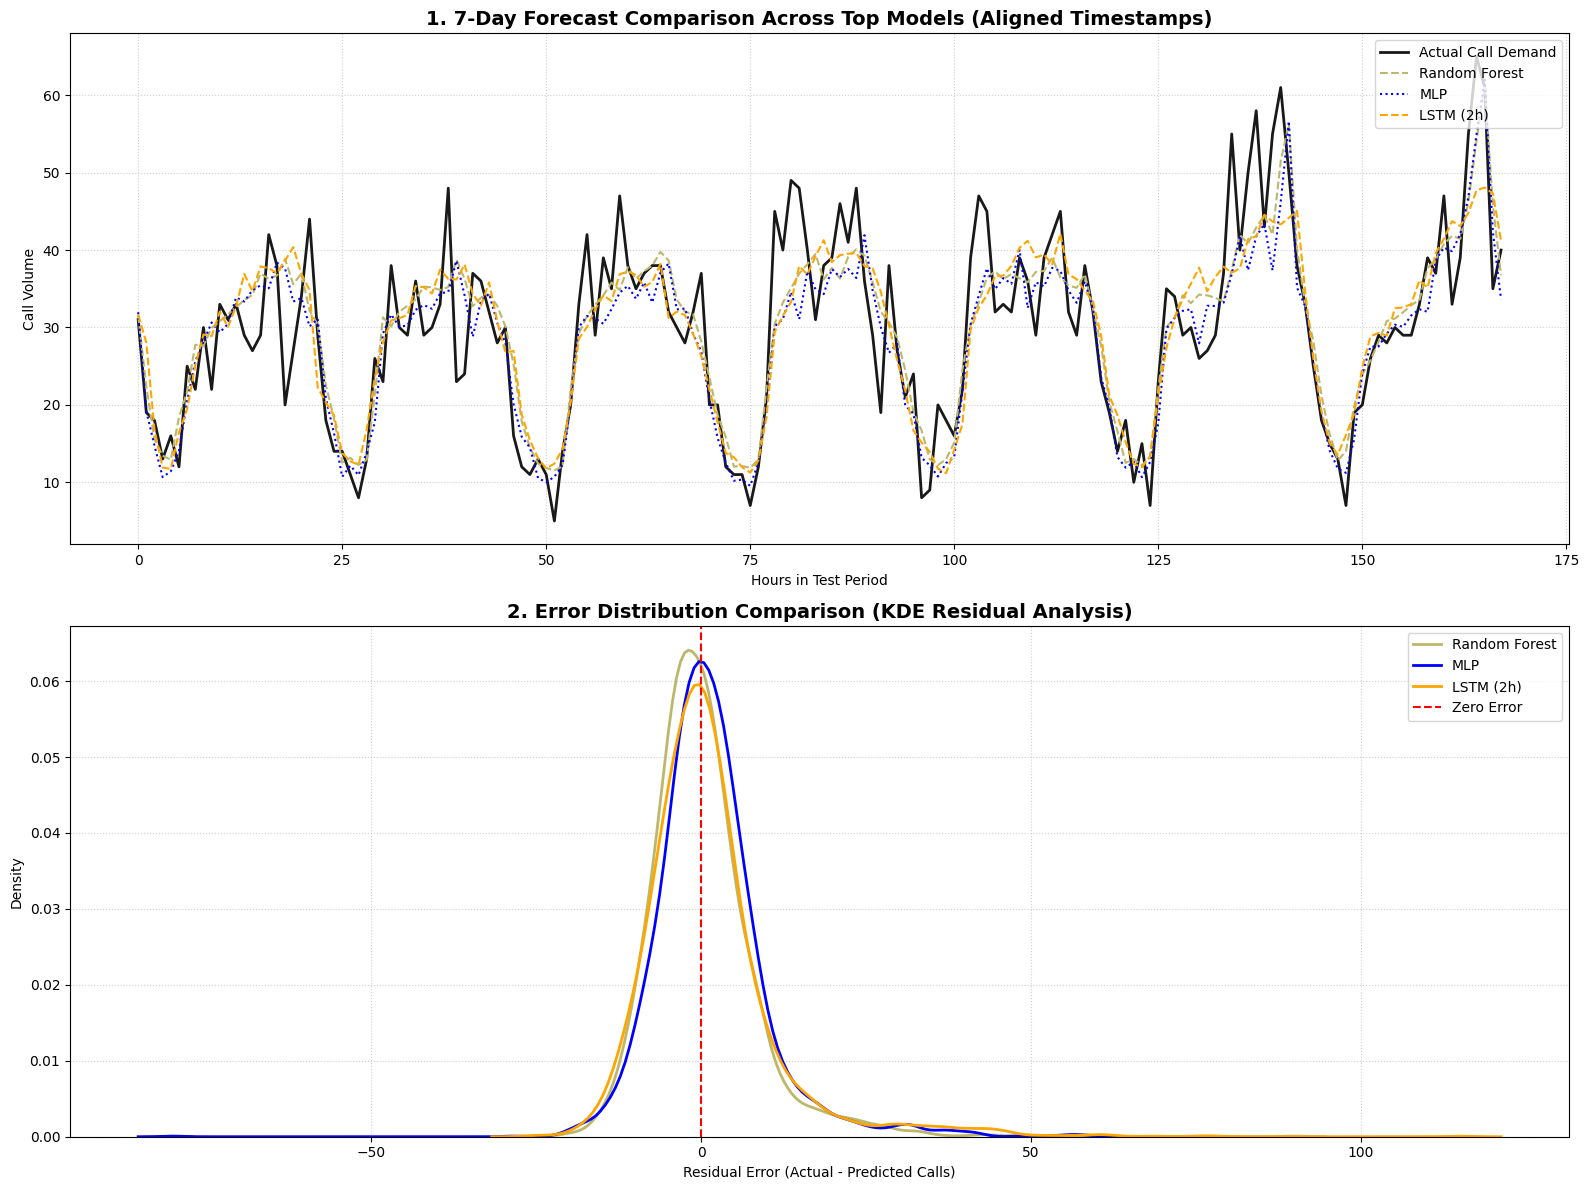

In [124]:
plt.figure(figsize=(16, 12))

# PLOT 1: 7-Day Hourly Forecast Comparison
plt.subplot(2, 1, 1)
time_window = 168  # 7 days * 24 hours

plt.plot(range(time_window), y_test_seq[:time_window], label='Actual Call Demand', color='black', lw=2.0, alpha=0.9)
plt.plot(range(time_window), rf_preds[:time_window], label='Random Forest', color='darkkhaki', linestyle='--', lw=1.5)
plt.plot(range(time_window), mlp_preds[:time_window], label='MLP', color='blue', linestyle=':', lw=1.5)
plt.plot(range(time_window), lstm_preds[:time_window], label=f'LSTM ({BEST_TIME_STEP}h)', color='orange', linestyle='--', lw=1.5)

plt.title('1. 7-Day Forecast Comparison Across Top Models (Aligned Timestamps)', fontsize=14, fontweight='bold')
plt.xlabel('Hours in Test Period')
plt.ylabel('Call Volume')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# PLOT 2: Residuals Distribution Comparison (Now using y_test_trimmed)
plt.subplot(2, 1, 2)
rf_residuals   = y_test_trimmed - rf_preds
mlp_residuals  = y_test_trimmed - mlp_preds
lstm_residuals = y_test_seq - lstm_preds

sns.kdeplot(rf_residuals, label='Random Forest', color='darkkhaki', lw=2)
sns.kdeplot(mlp_residuals, label='MLP', color='blue', lw=2)
sns.kdeplot(lstm_residuals, label=f'LSTM ({BEST_TIME_STEP}h)', color='orange', lw=2)

plt.axvline(0, color='red', linestyle='--', lw=1.5, label='Zero Error')
plt.title('2. Error Distribution Comparison (KDE Residual Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Residual Error (Actual - Predicted Calls)')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "master_model_forecast_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

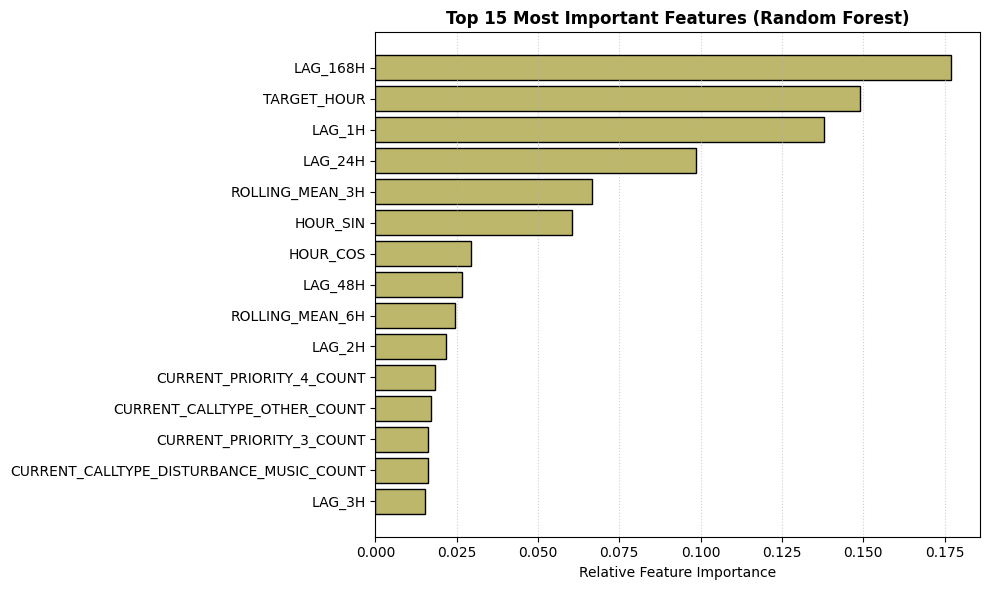

In [125]:
import matplotlib.pyplot as plt
import numpy as np

# Extract feature importances from the trained RF model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='darkkhaki', edgecolor='black')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Feature Importance')
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=12, fontweight='bold')
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(results_dir, "rf_feature_importance.png"), dpi=300, bbox_inches='tight')
plt.show()

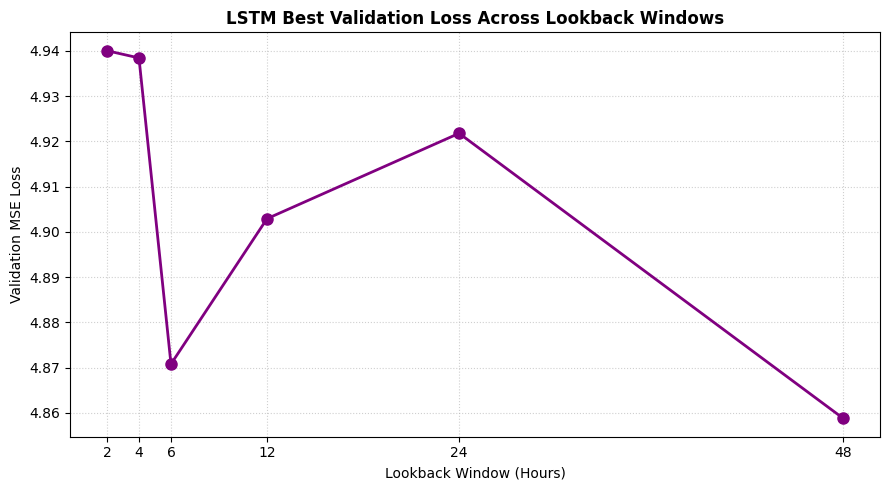

In [127]:
time_steps = [2, 4, 6, 12, 24, 48]
evaluated_steps = []
final_val_losses = []

for ts in time_steps:
    csv_path = os.path.join(project_folder, "models", "LSTM", f"lstm_history_timestep_{ts}.csv")
    if os.path.exists(csv_path):
        df_hist = pd.read_csv(csv_path)
        # Grab the best (minimum) validation loss achieved during training
        best_val_loss = df_hist['val_loss'].min()
        evaluated_steps.append(ts)
        final_val_losses.append(best_val_loss)

plt.figure(figsize=(9, 5))
plt.plot(evaluated_steps, final_val_losses, marker='o', color='purple', linewidth=2, markersize=8)
plt.title('LSTM Best Validation Loss Across Lookback Windows', fontsize=12, fontweight='bold')
plt.xlabel('Lookback Window (Hours)')
plt.ylabel('Validation MSE Loss')
plt.xticks(evaluated_steps)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "lstm_lookback_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()